# Basic usage

This notebook walks through the core workflow:
- Creating a hypergrid with `DenseHypergrid` and `SparseHypergrid`
- Fitting and incrementally updating
- Inspecting mass, edges, and shape
- Describing the distribution with `describe()`
- Converting to a dense array and probability vector
- Basic visualizations

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hypergrid import DenseHypergrid, SparseHypergrid, compute_edges

## 1. Generating sample data

In [2]:
rng = np.random.default_rng(42)
data = rng.standard_normal((5000, 3))
print(f"Data shape: {data.shape}")
print(f"Column means: {data.mean(axis=0).round(3)}")
print(f"Column stds:  {data.std(axis=0).round(3)}")

Data shape: (5000, 3)
Column means: [ 0.007 -0.001 -0.035]
Column stds:  [1.006 1.006 1.   ]


## 2. Computing bin edges automatically

In [3]:
edges = compute_edges(data, method="fd")  # Freedman-Diaconis

for d, e in enumerate(edges):
    print(f"Dim {d}: {len(e)-1} bins  [{e[0]:.2f}, {e[-1]:.2f}]")

Dim 0: 51 bins  [-3.89, 4.15]
Dim 1: 47 bins  [-3.65, 3.45]
Dim 2: 51 bins  [-4.39, 3.44]


## 3. DenseHypergrid â€” numpy backend

In [4]:
dense = DenseHypergrid(edges)
dense.fit(data)

mass = dense.get_mass()  # {tuple_index: float}
print(f"Non-empty bins: {len(mass)}")
print(f"Total mass:     {sum(mass.values()):.0f}  (should be ~{len(data)})")
print(f"Grid shape:     {dense.shape}")

Non-empty bins: 4144
Total mass:     4997  (should be ~5000)
Grid shape:     [51, 47, 51]


## 4. Incremental update

In [5]:
new_batch = rng.standard_normal((500, 3))
dense.update(new_batch)

print(f"Total mass after update: {sum(dense.get_mass().values()):.0f}")

Total mass after update: 5497


## 5. SparseHypergrid â€” sparse dict backend

In [6]:
sparse = SparseHypergrid(edges)
sparse.fit(data)

print(f"Non-empty bins (sparse): {len(sparse.get_mass())}")
print(f"Grid cells total:        {int(np.prod(sparse.shape))}")

Non-empty bins (sparse): 4144
Grid cells total:        122247


## 6. Describing the distribution

`describe()` returns a pandas DataFrame with summary statistics computed from
the binned histogram -- one column per dimension.
Statistics are derived from each dimension's marginal distribution:

| Row | Meaning |
|---|---|
| `count` | Total mass (number of data points binned) |
| `mean` | Probability-weighted mean of bin centres |
| `std` | Probability-weighted population standard deviation |
| `skewness` | Third standardised central moment (0 for symmetric distributions) |
| `kurtosis` | Excess kurtosis: fourth moment / std^4 - 3 (0 for a normal distribution) |
| `min` / `max` | Lower / upper edge of the outermost non-empty bin |
| `25%`, `50%`, `75%` | Percentiles via marginal CDF interpolation |

In [7]:
dense.describe()

,0,1,2
count,5497.000000,5497.000000,5497.000000
mean,0.006895,-0.003962,-0.030504
std,1.002774,1.004823,0.999355
skewness,0.002880,0.029218,0.006473
kurtosis,0.049386,0.053493,-0.116375
min,-3.887804,-3.648413,-4.389115
25%,-0.659176,-0.674558,-0.707197
50%,-0.011989,-0.013463,-0.035536
75%,0.690362,0.646047,0.642301
max,4.151241,3.302930,3.282495


### Custom percentiles

Pass any list of quantile positions in `[0, 1]`.

In [8]:
dense.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])

,0,1,2
count,5497.000000,5497.000000,5497.000000
mean,0.006895,-0.003962,-0.030504
std,1.002774,1.004823,0.999355
skewness,0.002880,0.029218,0.006473
kurtosis,0.049386,0.053493,-0.116375
min,-3.887804,-3.648413,-4.389115
5%,-1.627258,-1.667982,-1.684911
25%,-0.659176,-0.674558,-0.707197
50%,-0.011989,-0.013463,-0.035536
75%,0.690362,0.646047,0.642301


### Comparing describe() output with raw data statistics

The histogram-derived statistics approximate the true data statistics.
Accuracy improves with finer bins.

In [9]:
import pandas as pd
from scipy.stats import skew, kurtosis as sp_kurtosis

grid_stats = dense.describe()

# True statistics from raw data (dim 0 only for brevity)
print("=== Dim 0 comparison ==")
print(f"{'Statistic':<12} {'Grid':>10} {'Raw data':>10}")
print("-" * 34)
print(f"{'mean':<12} {grid_stats.loc['mean', 0]:>10.4f} {data[:, 0].mean():>10.4f}")
print(f"{'std':<12} {grid_stats.loc['std', 0]:>10.4f} {data[:, 0].std():>10.4f}")
print(f"{'skewness':<12} {grid_stats.loc['skewness', 0]:>10.4f} {skew(data[:, 0]):>10.4f}")
print(f"{'kurtosis':<12} {grid_stats.loc['kurtosis', 0]:>10.4f} {sp_kurtosis(data[:, 0]):>10.4f}")
print(f"{'25%':<12} {grid_stats.loc['25%', 0]:>10.4f} {np.percentile(data[:, 0], 25):>10.4f}")
print(f"{'50%':<12} {grid_stats.loc['50%', 0]:>10.4f} {np.percentile(data[:, 0], 50):>10.4f}")
print(f"{'75%':<12} {grid_stats.loc['75%', 0]:>10.4f} {np.percentile(data[:, 0], 75):>10.4f}")

=== Dim 0 comparison ==
Statistic          Grid   Raw data
----------------------------------
mean             0.0069     0.0071
std              1.0028     1.0055
skewness         0.0029     0.0297
kurtosis         0.0494     0.1305
25%             -0.6592    -0.6594
50%             -0.0120    -0.0177
75%              0.6904     0.6886


## 7. Converting to a dense array and probability vector

In [10]:
arr = dense.to_dense()  # numpy array
print(f"Dense array shape: {arr.shape}")
print(f"Array sum:         {arr.sum():.0f}")

vec = dense.to_vector()  # flat probability vector
print(f"\nProbability vector length: {len(vec)}")
print(f"Vector sum:                {vec.sum():.6f}")

Dense array shape: (51, 47, 51)
Array sum:         5497

Probability vector length: 122247
Vector sum:                1.000000


## 8. Visualizations

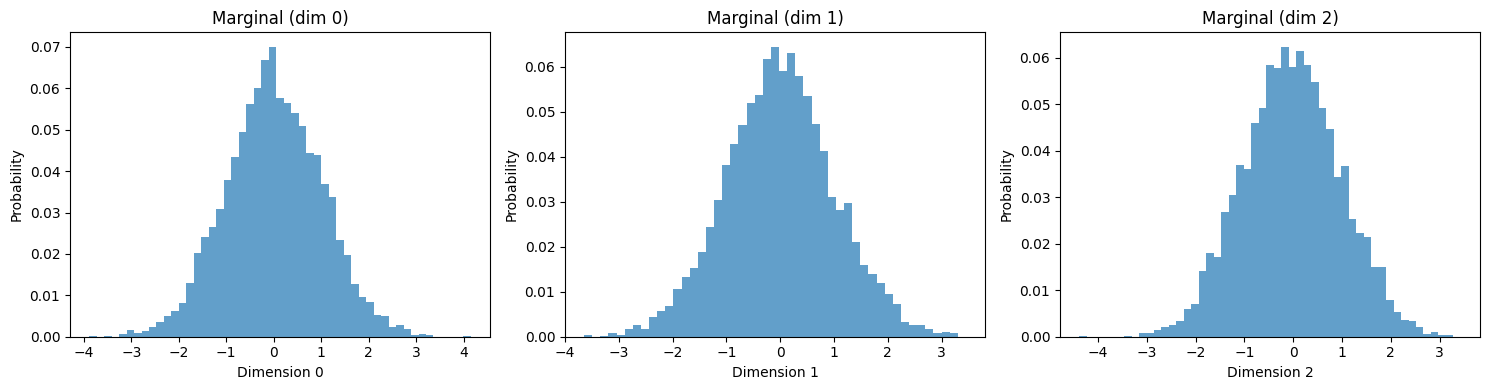

In [11]:
dense.plot_all_marginals()

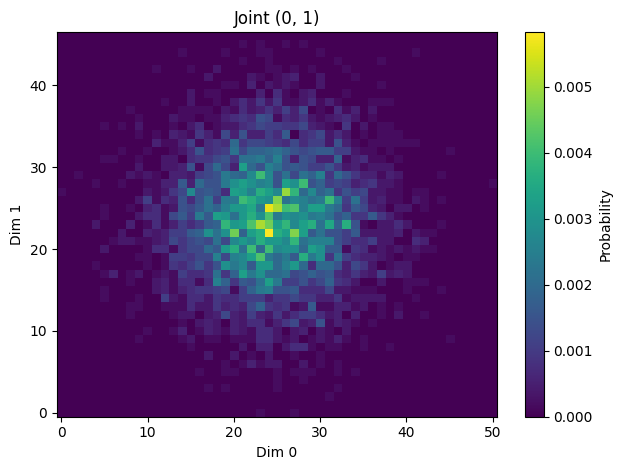

In [12]:
dense.plot_joint(dim_x=0, dim_y=1)

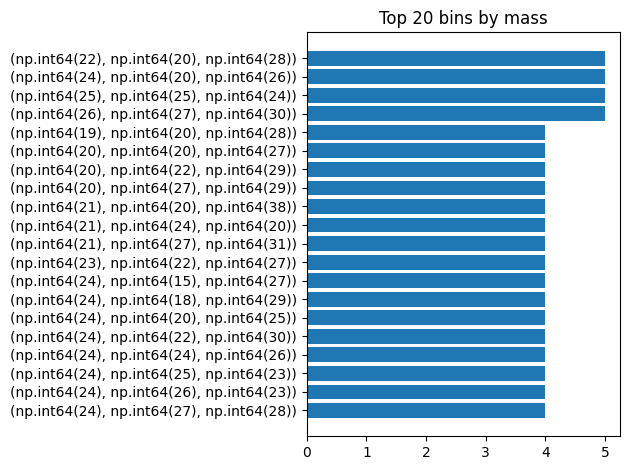

In [13]:
dense.plot_top_bins(k=20)

## 9. Rebinning onto coarser edges

In [14]:
coarse_edges = [np.linspace(e[0], e[-1], 6) for e in edges]
rebinned = dense.rebin_to(coarse_edges)  # returns dict

print(f"Bins in rebinned grid: {len(rebinned)}")
print(f"Mass conserved:        {sum(rebinned.values()):.0f}")

Bins in rebinned grid: 78
Mass conserved:        5497
